In [1]:
import numpy as np
import torch
from matplotlib import pyplot as plt

device='cuda'

In [2]:
data=np.load("/home/kjaworski/Pulpit/Temporal_thermal_imaging/Bscan_thermography_dataset/Experimental_sample/2026_03_18_CFRP_FBH_5s_30s_top_symetrical.npz",allow_pickle=True)
data=data['data']
data=torch.from_numpy(data).float()

In [6]:
data=data/100-273.15

In [21]:
data.size()

torch.Size([1759, 480, 640])

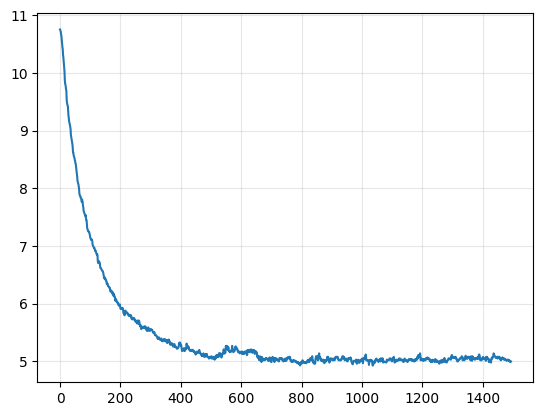

In [18]:
plt.plot(data[265:,240,320])
plt.grid(alpha=0.3)

In [13]:
data=data-data[:15].mean()

In [19]:
data_cool=data[265:]

In [20]:
from pulse_method.toolbox_pulse import *

In [25]:
analyzer = thermograms(height=480, width=640)

In [51]:
data=data.to(device)
data_cool=data_cool.to(device)

In [27]:
phase,magnitude=analyzer.PPT_torch(data)

In [29]:
eof,_=analyzer.PCT_torch(data)

In [52]:
tsr,_,_=analyzer.TSR_torch(data_cool)

In [31]:
HOS=analyzer.HOS_torch(data)

In [32]:
DMDs,_=analyzer.DMD_torch(data)

Text(0, 0.5, 'Height [px]')

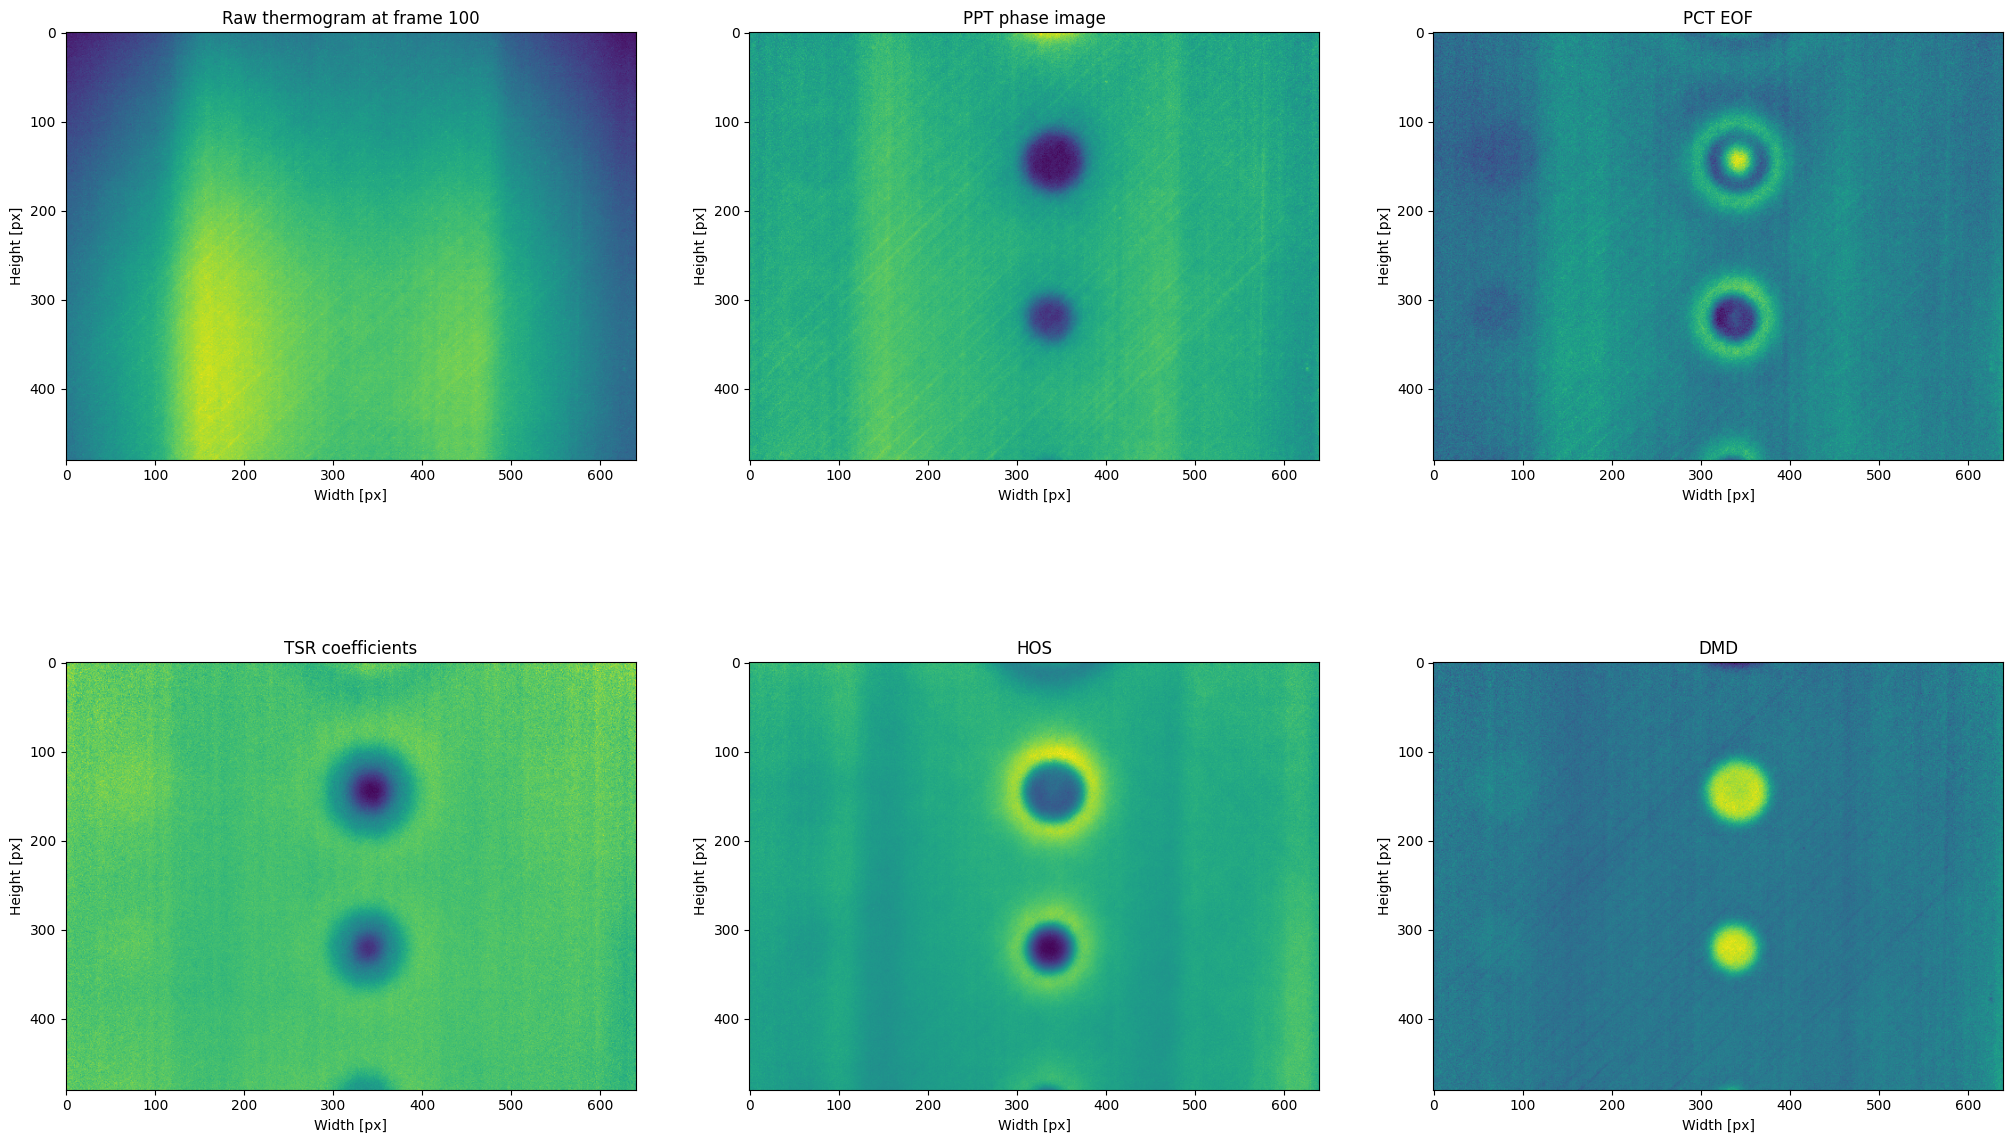

In [114]:
plt.figure(figsize=(25,15))
plt.subplot(2,3,1)
plt.imshow(data[100].cpu())
plt.title("Raw thermogram at frame 100")
plt.xlabel('Width [px]')
plt.ylabel("Height [px]")

plt.subplot(2,3,2)
plt.imshow(phase[4].cpu())
plt.title("PPT phase image")
plt.xlabel('Width [px]')
plt.ylabel("Height [px]")

plt.subplot(2,3,3)
plt.imshow(eof[3].cpu())
plt.title("PCT EOF")
plt.xlabel('Width [px]')
plt.ylabel("Height [px]")

plt.subplot(2,3,4)
plt.imshow(tsr[5].cpu())
plt.title("TSR coefficients")
plt.xlabel('Width [px]')
plt.ylabel("Height [px]")


plt.subplot(2,3,5)
plt.imshow(HOS[1].cpu())
plt.title("HOS")
plt.xlabel('Width [px]')
plt.ylabel("Height [px]")

plt.subplot(2,3,6)
plt.imshow(DMDs[-1].imag.cpu())
plt.title("DMD")
plt.xlabel('Width [px]')
plt.ylabel("Height [px]")